In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "Kelas D_Happiness and Satisfaction.csv",
    sep=';',
    decimal=','
)

/tmp/ipykernel_1604/2181987214.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors   = [cm.get_cmap('YlGn')(norm(v)) for v in df_agg['Rata_rata']]


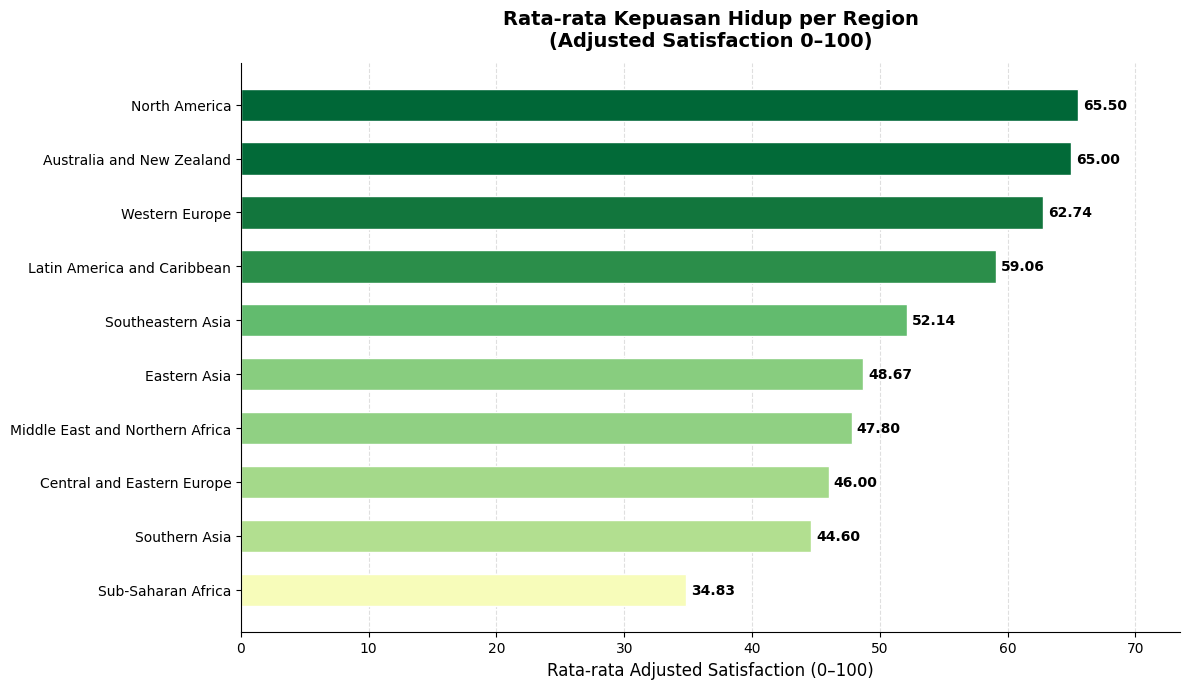

In [ ]:
# Kategori A (Agregasi)
# Rata-rata adjusted_satisfaction per Region → Horizontal Bar Chart

# Bersihkan nama kolom
df.columns = df.columns.str.strip()
df['Region'] = df['Region'].str.replace("'", "", regex=False).str.strip()

sat_col = 'adjusted_satisfaction (0-100)'

# Agregasi rata-rata per Region, urutkan dari terbesar
df_agg = (
    df.groupby('Region')[sat_col]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={sat_col: 'Rata_rata'})
    .sort_values('Rata_rata', ascending=True)
)

# Plot Horizontal Bar Chart
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(12, 7))

norm     = mcolors.Normalize(vmin=df_agg['Rata_rata'].min() - 5, vmax=df_agg['Rata_rata'].max() + 5)
colors   = [cm.get_cmap('YlGn')(norm(v)) for v in df_agg['Rata_rata']]

bars = ax.barh(df_agg['Region'], df_agg['Rata_rata'], color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, df_agg['Rata_rata']):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlabel('Rata-rata Adjusted Satisfaction (0–100)', fontsize=12)
ax.set_title('Rata-rata Kepuasan Hidup per Region\n(Adjusted Satisfaction 0–100)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0, df_agg['Rata_rata'].max() + 8)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

Median adjusted_satisfaction Sub-Saharan Africa: 36.0
Jumlah negara di atas median: 13
          Country  adjusted_satisfaction (0-100)
108  South Africa                             49
69      Mauritius                             48
74        Nigeria                             43
26       Djibouti                             43
38          Ghana                             41
94        Senegal                             41
89         Rwanda                             40
59        Lesotho                             40
96           Chad                             40
104        Uganda                             39
8    Burkina Faso                             37
58        Liberia                             37
109        Zambia                             37


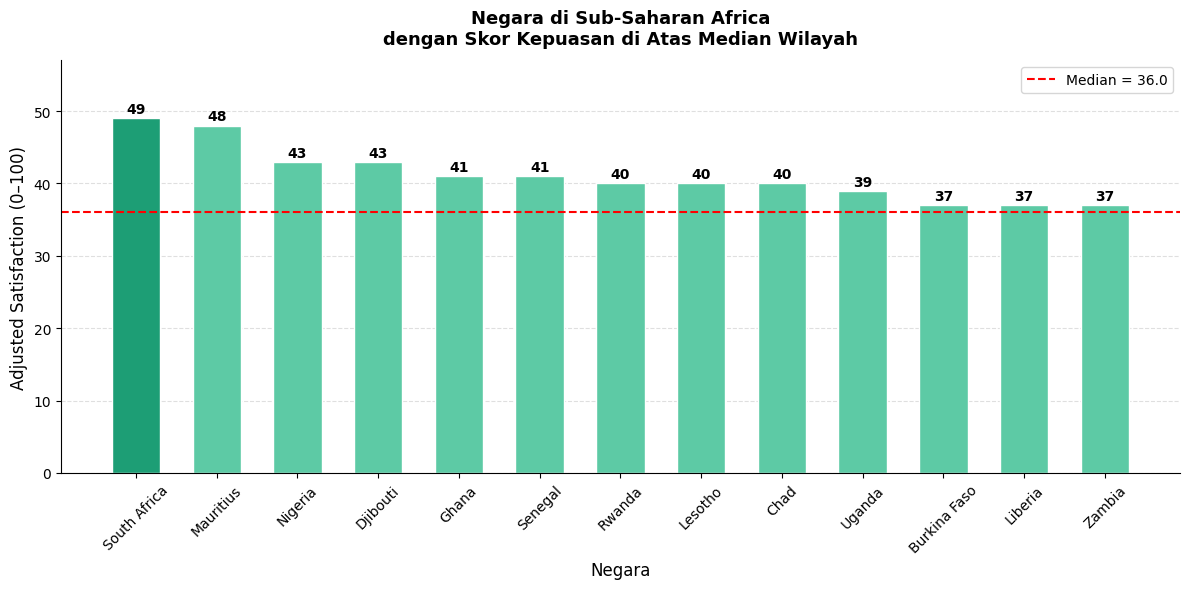

In [ ]:
# Kategori B

sat_col = 'adjusted_satisfaction (0-100)'

# Bersihkan kolom Region dari tanda kutip
df['Region_clean'] = df['Region'].str.replace("'", "").str.strip()

# Filter hanya Sub-Saharan Africa
df_ssa = df[df['Region_clean'] == 'Sub-Saharan Africa'].copy()

# Hitung median wilayah
median_ssa = df_ssa[sat_col].median()
print(f"Median adjusted_satisfaction Sub-Saharan Africa: {median_ssa}")

# Filter negara di atas median
df_above = df_ssa[df_ssa[sat_col] > median_ssa].sort_values(sat_col, ascending=False)

print(f"Jumlah negara di atas median: {len(df_above)}")
print(df_above[['Country', sat_col]])

# Plot Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

max_val = df_above[sat_col].max()
colors = ['#1D9E75' if v == max_val else '#5DCAA5' for v in df_above[sat_col]]

bars = ax.bar(df_above['Country'], df_above[sat_col], color=colors, edgecolor='white', width=0.6)

# Label nilai di atas bar
for bar, val in zip(bars, df_above[sat_col]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Garis median
ax.axhline(y=median_ssa, color='red', linestyle='--', linewidth=1.5,
           label=f'Median = {median_ssa:.1f}')

ax.set_xlabel('Negara', fontsize=12)
ax.set_ylabel('Adjusted Satisfaction (0–100)', fontsize=12)
ax.set_title('Negara di Sub-Saharan Africa\ndengan Skor Kepuasan di Atas Median Wilayah',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, max_val + 8)
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_la6yout'

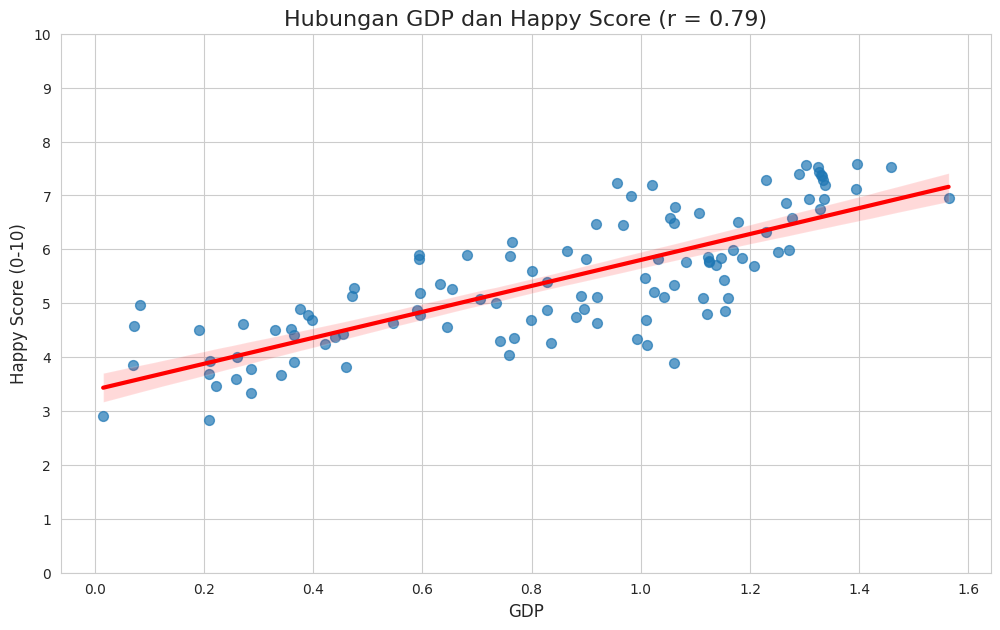

In [ ]:
# Kategori C (Nabila)

korelasi = df['GDP'].corr(df['Happy Score (0-10)'])

plt.figure(figsize=(12,7))

sns.set_style("whitegrid")

sns.regplot(
    data=df,
    x='GDP',
    y='Happy Score (0-10)',
    scatter_kws={
        's':50,
        'alpha':0.7
    },
    line_kws={
        'linewidth':3,
        'color':'red'
    }
)

plt.title(
    f'Hubungan GDP dan Happy Score (r = {korelasi:.2f})',
    fontsize=16
)

plt.xlabel('GDP', fontsize=12)
plt.ylabel('Happy Score (0-10)', fontsize=12)

# Skala Happy Score asli
plt.ylim(0,10)
plt.yticks(range(0,11,1))

plt.tight_la6yout()

plt.show()

korelasi = df['GDP'].corr(df['Happy Score (0-10)'])

print(f"Nilai Korelasi = {korelasi:.2f}")

if korelasi > 0:
    print("Terdapat korelasi positif antara GDP dan Happy Score.")
else:
    print("Terdapat korelasi negatif antara GDP dan Happy Score.")

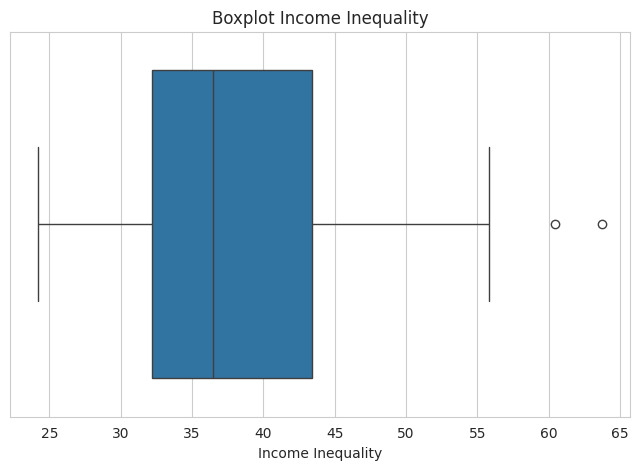

Negara yang termasuk outlier:
          Country  income_inequality
14       Botswana          60.460000
108  South Africa          63.726667


In [ ]:
# Kategori D (Nisrina)
# Mencari sebaran dan pencilan pada income_inequality

plt.figure(figsize=(8,5))
sns.boxplot(x=df['income_inequality'])

plt.title('Boxplot Income Inequality')
plt.xlabel('Income Inequality')
plt.show()

# Mencari outlier dengan metode IQR
Q1 = df['income_inequality'].quantile(0.25)
Q3 = df['income_inequality'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier = df[
    (df['income_inequality'] < lower_bound) |
    (df['income_inequality'] > upper_bound)
]

print("Negara yang termasuk outlier:")
print(outlier[['Country', 'income_inequality']])
